# Carga y limpieza de transacciones retail

Primer paso del pipeline: dejar el histórico listo para agregar demanda.

1. Cargar Online Retail II (o el sample local)
2. Diagnosticar nulos y duplicados
3. Aplicar las reglas de limpieza
4. Ventas por producto en el **último trimestre**

Dataset completo: `data/raw/online_retail_II.csv`. Sample: `data/raw/sample_online_retail.csv`.

> Requiere el paquete instalado en modo editable: `pip install -e .` desde la raíz del repo.


In [1]:
import pandas as pd

from inventario_ecommerce import config
from inventario_ecommerce.dataset import load_transactions, save_processed
from inventario_ecommerce.features import clean_transactions, sales_by_product_last_quarter
from inventario_ecommerce.plots import plot_top_products_by_sales

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Raw data dir:", config.RAW_DATA_DIR)


Raw data dir: C:\code\proyecto-a-inventario-ecommerce\data\raw


## 1. Carga del dataset

Por defecto se usa el CSV completo (~1.07M filas). Para un smoke-test, cambia `RAW_FILE` a `config.RAW_DATA_DIR / "sample_online_retail.csv"`.


In [2]:
RAW_FILE = config.DEFAULT_RAW_FILE

df_raw = load_transactions(RAW_FILE)
print(f"Archivo: {RAW_FILE.name}")
print(f"Filas: {len(df_raw):,} | Columnas: {list(df_raw.columns)}")
df_raw.head()


Archivo: online_retail_II.csv
Filas: 1,067,371 | Columnas: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## 2. Diagnóstico de calidad


In [3]:
print("=== Info ===")
df_raw.info()

print("\n=== Nulos por columna ===")
nulls = df_raw.isna().sum().sort_values(ascending=False)
null_pct = (df_raw.isna().mean() * 100).round(2)
quality = pd.DataFrame({"nulos": nulls, "%": null_pct})
display(quality[quality["nulos"] > 0])

print("\n=== Duplicados exactos ===")
print(df_raw.duplicated().sum())


=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB

=== Nulos por columna ===


,nulos,%
Customer ID,243007,22.77
Description,4382,0.41



=== Duplicados exactos ===


34335


## 3. Limpieza

`clean_transactions` aplica:

- Drop de filas con `StockCode`, `Description`, `InvoiceDate` o `Price` nulos
- Solo `Quantity > 0` y `Price >= 0` (fuera devoluciones y precios inválidos)
- Fuera códigos y descripciones que no son inventario físico (`POST`, `DOT`, postage, etc.)
- `Sales = Quantity * Price`


In [4]:
df_clean = clean_transactions(df_raw)

print(f"Filas raw:       {len(df_raw):,}")
print(f"Filas limpias:   {len(df_clean):,}")
print(f"Filas removidas: {len(df_raw) - len(df_clean):,}")
print(f"Rango de fechas: {df_clean['InvoiceDate'].min()} -> {df_clean['InvoiceDate'].max()}")
print(f"Nulos residuales: {int(df_clean.isna().sum().sum())}")
df_clean.head()


Filas raw:       1,067,371
Filas limpias:   1,038,067
Filas removidas: 29,304
Rango de fechas: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Nulos residuales: 235372


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,30.00


## 4. Ventas por producto — último trimestre

Ventana: 3 meses hacia atrás desde la fecha máxima del dataset.


In [5]:
sales_q = sales_by_product_last_quarter(df_clean)

period_start = sales_q.attrs.get("period_start")
period_end = sales_q.attrs.get("period_end")
print(f"Periodo: {period_start.date()} -> {period_end.date()}")
print(f"Productos con ventas: {len(sales_q):,}")
print(f"Ventas del trimestre: {sales_q['TotalSales'].sum():,.2f}")
sales_q.head(15)


Periodo: 2011-09-10 -> 2011-12-09
Productos con ventas: 3,393
Ventas del trimestre: 3,963,910.00


,StockCode,Description,QuantitySold,TotalSales,NTransactions
0,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1
1,23084,RABBIT NIGHT LIGHT,25694,"56,894.39",746
2,22086,PAPER CHAIN KIT 50'S CHRISTMAS,15179,"50,907.49",902
3,22423,REGENCY CAKESTAND 3 TIER,3161,"40,183.50",558
4,85099B,JUMBO BAG RED RETROSPOT,15812,"31,101.76",657
5,22197,POPCORN HOLDER,27526,"27,002.40",555
6,23355,HOT WATER BOTTLE KEEP CALM,5380,"26,667.48",736
7,85123A,WHITE HANGING HEART T-LIGHT HOLDER,9186,"26,123.26",611
8,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,7761,"24,317.65",627
9,22114,HOT WATER BOTTLE TEA AND SYMPATHY,4249,"23,529.57",509


Guardado en: C:\code\proyecto-a-inventario-ecommerce\data\processed\sales_last_quarter_by_product.csv


WindowsPath('C:/code/proyecto-a-inventario-ecommerce/reports/figures/top_products_last_quarter.png')

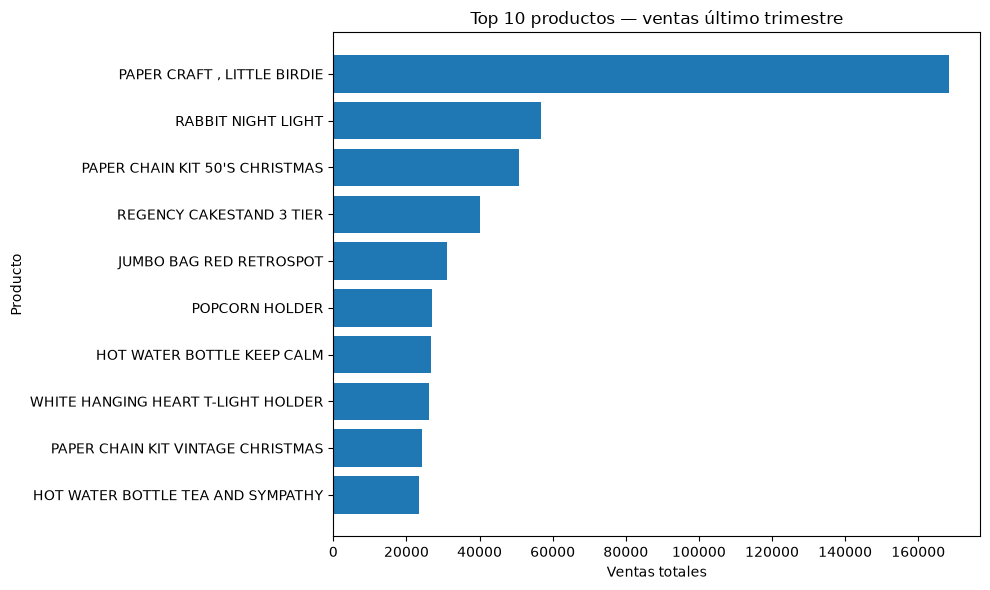

In [6]:
out_path = save_processed(sales_q, "sales_last_quarter_by_product.csv")
print(f"Guardado en: {out_path}")

plot_top_products_by_sales(sales_q, top_n=10, save=True)


## Ver también

- `notebooks/02_forecast_reorder_baseline.ipynb` — ABC, forecast y punto de reorden
- `notebooks/03_demand_hygiene.ipynb` — ceros en el calendario y recorte de outliers
- `notebooks/04_forecast_class_a.ipynb` — ETS vs media móvil en clase A
